In [1]:
import pandas as pd

In [2]:
df4 = pd.read_csv('train_test_network.csv')

# Data Preprocessing and Exploration

In [3]:
# Create 'stage' attribute based on 'type' column
def assign_stage(attack_type):
    s = str(attack_type).lower()
    
    # Check for normal/benign
    if "normal" in s:
        return 0
    
    # Stage 1: Reconnaissance
    if any(k in s for k in ["scann","scan","recon","nmap","probe","crawler","httrack"]):
        return 1
    
    # Stage 2: Privilege Escalation / Exploitation
    if any(k in s for k in ["injection","xss","mitm","sql","password","login","auth","brute","slowloris","exploit"]):
        return 2
    
    # Stage 3: Access / Impact
    if any(k in s for k in ["backdoor","ransom","ransomware","ddos","dos","bot","c2","exfil","impact"]):
        return 3
    
    # Default: 0 for other attacks not in above categories
    return 0

# Apply the function to create the 'stage' column
df4['stage'] = df4['type'].apply(assign_stage)

# Display distribution of stages
print("Stage Distribution:")
print(df4['stage'].value_counts().sort_index())
print("\nStage Mapping:")
print("0: Normal/Benign or Other")
print("1: Stage 1 - Reconnaissance")
print("2: Stage 2 - Privilege Escalation / Exploitation")
print("3: Stage 3 - Access / Impact")

Stage Distribution:
stage
0    50000
1    20000
2    61043
3    80000
Name: count, dtype: int64

Stage Mapping:
0: Normal/Benign or Other
1: Stage 1 - Reconnaissance
2: Stage 2 - Privilege Escalation / Exploitation
3: Stage 3 - Access / Impact


## Unique IPs Analysis for IP Splitting

1. Identical IPs need need to be in train only or test only and cannot be in both 
2. IP splitting is necessary for the model to be able to be generalized through unbiased evaluation (Unbiased evaluation -> Clear lack of predictive strength -> Solve)
3. If no IP splitting (Biased evaluation -> Unidentified lack of predictive strength due to evaluatiions showing high accuracy -> Unsolved/un-generalized model)


In [13]:
# Group by stage and list unique src_ips
print("="*50)
print("Unique src_ips grouped by stage")
print("="*50)

for stage in sorted(df4['stage'].unique()):
    stage_data = df4[df4['stage'] == stage]
    unique_src_ips = stage_data['src_ip'].unique()
    print(f"\nStage: {stage}")
    print(f"Count of unique src_ips: {len(unique_src_ips)}")
    print(f"src_ips: {sorted(unique_src_ips)}")


# Find IPs that are the same across different stages
print("="*60)
print("IPs that appear in multiple stages")
print("="*60)

stages = sorted(df4['stage'].unique())
stage_ips = {}

# Collect IPs for each stage
for stage in stages:
    stage_ips[stage] = set(df4[df4['stage'] == stage]['src_ip'].unique())
    print(f"\nStage {stage}: {len(stage_ips[stage])} unique IPs")

# Find common IPs between all pairs of stages
print("\n" + "="*60)
print("Common IPs between stages:")
print("="*60)

for i, stage1 in enumerate(stages):
    for stage2 in stages[i+1:]:
        common = stage_ips[stage1] & stage_ips[stage2]
        if common:
            print(f"\nStage {stage1} & Stage {stage2}: {len(common)} common IPs")
            print(f"IPs: {sorted(common)}")
        else:
            print(f"\nStage {stage1} & Stage {stage2}: No common IPs")

# Find IPs present in all stages
all_common = set.intersection(*stage_ips.values()) if stage_ips else set()
print(f"\n" + "="*60)
print(f"IPs present in ALL stages: {len(all_common)}")
if all_common:
    print(f"IPs: {sorted(all_common)}")




Unique src_ips grouped by stage

Stage: 0
Count of unique src_ips: 40
src_ips: ['172.17.0.5', '172.17.0.7', '172.17.0.8', '192.168.1.1', '192.168.1.103', '192.168.1.133', '192.168.1.152', '192.168.1.169', '192.168.1.17', '192.168.1.180', '192.168.1.184', '192.168.1.186', '192.168.1.190', '192.168.1.191', '192.168.1.192', '192.168.1.193', '192.168.1.194', '192.168.1.195', '192.168.1.250', '192.168.1.30', '192.168.1.46', '192.168.1.49', '192.168.1.6', '192.168.1.79', '199.115.158.193', '2405:6e00:10ce:2c00:20c:29ff:fed2:b002', '2405:6e00:10ce:2c00:20c:29ff:feee:e07a', '2405:6e00:10ce:2c00:8520:4eba:6770:702a', '2405:6e00:10ce:2c00:9064:17:85d2:57d4', '2405:6e00:10ce:2c00:c058:dbaa:f212:a2d8', 'fe80::1087:c341:7263:ead3', 'fe80::343b:2cf:e9fb:6570', 'fe80::601f:9cde:4832:2f3f', 'fe80::76:ad3e:1329:a7fd', 'fe80::8520:4eba:6770:702a', 'fe80::855:e4ef:de26:7aca', 'fe80::e4a6:b91f:48f3:ac01', 'fe80::ee1f:72ff:fef1:286d', 'fe80::f554:8774:9968:b60b', 'fe80::ffff:ffff:ffff']

Stage: 1
Count of 

[ordering] forced by CKC stage order (S1→S2→S3)

Pseudo-time per stage:
                                               count            min  \
_stage                                                                
Stage 1 : Reconnaissance                        8651       0.000000   
Stage 2 : Privilege Escalation / Exploitation  17582    2205.745976   
Stage 3 : Access / Impact                      35352   24747.244329   
Normal / Benign                                   48  284672.909489   

                                                      median            max  
_stage                                                                       
Stage 1 : Reconnaissance                          176.444476    2204.427564  
Stage 2 : Privilege Escalation / Exploitation   19073.849179   24747.243691  
Stage 3 : Access / Impact                      226222.013619  284672.902476  
Normal / Benign                                284714.665142  284900.728219  



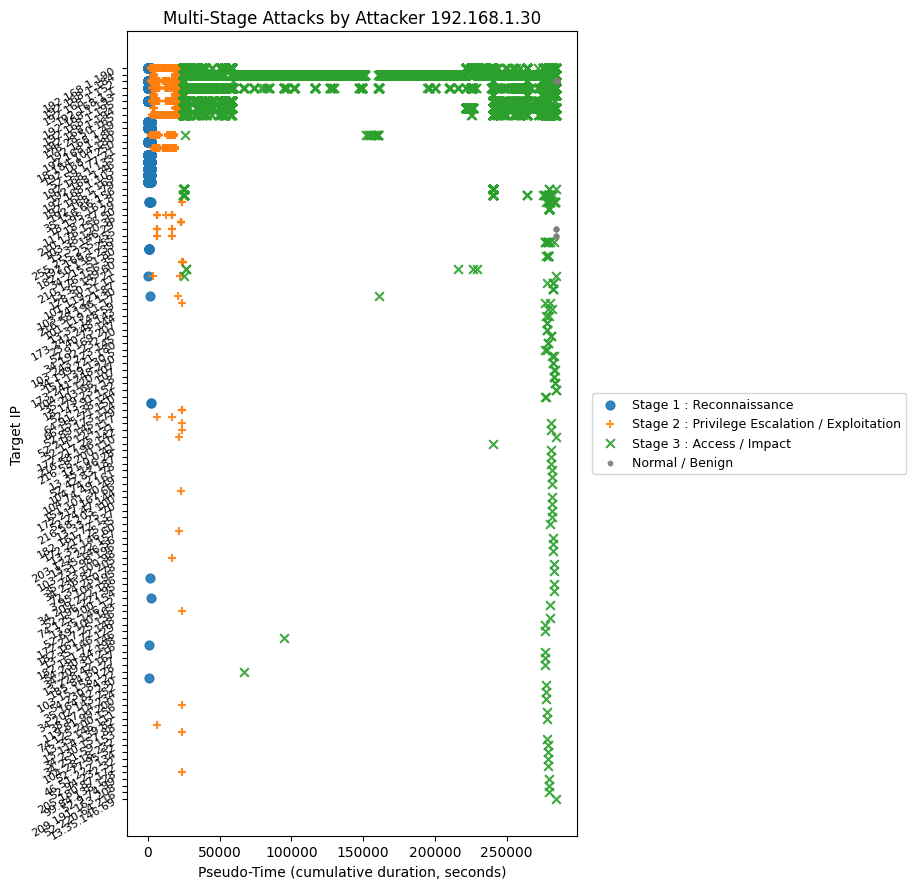

[saved] multistage_ckc_staged.png


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_ckc_staged_pseudotime(
    df4,
    ATTACKER_IP="192.168.1.30",
    DURATION_COL="duration",
    SRC_COL="src_ip",
    DST_COL="dst_ip",
    TYPE_COL="type",
    OUT_PNG="multistage_ckc_staged.png",
    FIGSIZE=(12,9),
    ORDER_BY_COL=None,        # kalau kamu punya kolom urutan asli, isi di sini (mis. "flow_start")
    FORCE_STAGE_ORDER=True    # True = pastikan Stage1 di kiri, lalu Stage2, Stage3
):
    df = df4.copy()

    # Filter attacker dan pastikan duration numerik
    df = df[df[SRC_COL].astype(str) == str(ATTACKER_IP)].copy()
    if df.empty:
        raise ValueError(f"Tidak ada data untuk attacker {ATTACKER_IP}")
    df[DURATION_COL] = pd.to_numeric(df[DURATION_COL], errors="coerce").fillna(0.0)

    # Mapping type -> stage (sesuai daftar kamu)
    def map_stage_from_type(s):
        s = str(s).lower()
        if "normal" in s: return "Normal / Benign"
        if any(k in s for k in ["scann","scan","recon","nmap","probe","crawler","httrack"]):
            return "Stage 1 : Reconnaissance"
        if any(k in s for k in ["injection","xss","mitm","sql","password","login","auth","brute","slowloris","exploit"]):
            return "Stage 2 : Privilege Escalation / Exploitation"
        if any(k in s for k in ["backdoor","ransom","ransomware","ddos","dos","bot","c2","exfil","impact"]):
            return "Stage 3 : Access / Impact"
        return "Unknown/Other"

    df["_stage"] = df[TYPE_COL].astype(str).apply(map_stage_from_type)

    # === KUNCI PERBAIKAN ===
    # Jika tidak ada ORDER_BY_COL (timestamp asli), urutkan berdasarkan urutan stage,
    # supaya Stage 1 selalu muncul di kiri, dilanjut Stage 2, lalu Stage 3.
    stage_rank = {
        "Stage 1 : Reconnaissance": 1,
        "Stage 2 : Privilege Escalation / Exploitation": 2,
        "Stage 3 : Access / Impact": 3,
        "Normal / Benign": 4,
        "Unknown/Other": 5
    }

    if ORDER_BY_COL and ORDER_BY_COL in df.columns:
        df = df.sort_values(by=ORDER_BY_COL).reset_index(drop=True)
        ordering_note = f"ordered by '{ORDER_BY_COL}'"
    elif FORCE_STAGE_ORDER:
        df["_stage_rank"] = df["_stage"].map(stage_rank).fillna(99)
        # stabilkan urutan dalam stage dengan index asli supaya pola aslinya masih kebaca
        df = df.sort_values(by=["_stage_rank"]).reset_index(drop=True)
        ordering_note = "forced by CKC stage order (S1→S2→S3)"
    else:
        df = df.sort_index().reset_index(drop=True)
        ordering_note = "by original row order"

    # Hitung pseudo-time SETELAH pengurutan
    med = float(np.nanmedian(df[DURATION_COL]))
    scale = 1.0 if med <= 1000 else 1/1000.0  # ms → s jika perlu
    df["_pseudo_time"] = (df[DURATION_COL] * scale).cumsum().astype(float)

    # Diagnostik singkat (cek urutan sudah sesuai ekspektasi)
    diag = df.groupby("_stage")["_pseudo_time"].agg(["count","min","median","max"]).sort_values("median")
    print(f"[ordering] {ordering_note}\n\nPseudo-time per stage:\n{diag}\n")

    # Sumbu-Y: target IP
    df["_dst_str"] = df[DST_COL].astype(str)
    dst_order = df["_dst_str"].value_counts().index.tolist()[::-1]
    df["_dst_cat"] = pd.Categorical(df["_dst_str"], categories=dst_order, ordered=True)

    # Style per stage
    colors = {
        "Stage 1 : Reconnaissance":"tab:blue",
        "Stage 2 : Privilege Escalation / Exploitation":"tab:orange",
        "Stage 3 : Access / Impact":"tab:green",
        "Normal / Benign":"tab:gray",
        "Unknown/Other":"tab:red"
    }
    markers = {
        "Stage 1 : Reconnaissance":"o",
        "Stage 2 : Privilege Escalation / Exploitation":"+",
        "Stage 3 : Access / Impact":"x",
        "Normal / Benign":".",
        "Unknown/Other":"D"
    }

    # Plot
    plt.figure(figsize=FIGSIZE)
    ax = plt.gca()
    for stg in ["Stage 1 : Reconnaissance",
                "Stage 2 : Privilege Escalation / Exploitation",
                "Stage 3 : Access / Impact",
                "Normal / Benign",
                "Unknown/Other"]:
        sub = df[df["_stage"] == stg]
        if sub.empty: continue
        ax.scatter(sub["_pseudo_time"], sub["_dst_cat"].cat.codes,
                   s=40, alpha=0.9,
                   color=colors[stg], marker=markers[stg], label=stg)

    ax.set_yticks(range(len(dst_order)))
    ax.set_yticklabels(dst_order, fontsize=8, rotation=30, ha="right")
    ax.set_xlabel("Pseudo-Time (cumulative duration, seconds)")
    ax.set_ylabel("Target IP")
    ax.set_title(f"Multi-Stage Attacks by Attacker {ATTACKER_IP}")
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
    plt.tight_layout(rect=[0,0,0.78,1])
    plt.savefig(OUT_PNG, dpi=200, bbox_inches='tight')
    plt.show()
    print(f"[saved] {OUT_PNG}")

    return df[["_pseudo_time", SRC_COL, DST_COL, TYPE_COL, "_stage"]]

# ==== contoh pakai ====
cleaned = plot_ckc_staged_pseudotime(
    df4,
    ATTACKER_IP="192.168.1.30",
    DURATION_COL="duration",
    SRC_COL="src_ip",
    DST_COL="dst_ip",
    TYPE_COL="type",
    ORDER_BY_COL=None,          # kalau ada kolom waktu asli, ganti None -> "nama_kolom"
    FORCE_STAGE_ORDER=True      # pastikan S1 di kiri, lalu S2, lalu S3
)


# Initial Testing

In [15]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# =====================
# 1. Copy dataset
# =====================
df = df4.copy()

# =====================
# 2. Split by src_ip
# =====================
unique_ips = df['src_ip'].unique()
np.random.seed(42)
np.random.shuffle(unique_ips)

split_idx = int(0.8 * len(unique_ips))
train_ips = unique_ips[:split_idx]
test_ips  = unique_ips[split_idx:]

train_df = df[df['src_ip'].isin(train_ips)].copy()
test_df  = df[df['src_ip'].isin(test_ips)].copy()

groups = train_df['src_ip']

print("Train size:", train_df.shape)
print("Test size :", test_df.shape)

# =====================
# 3. Drop leakage
# =====================
drop_cols = [
    'src_ip','dst_ip','src_port','dst_port',
    'dns_query','http_uri','http_user_agent',
    'ssl_subject','ssl_issuer','weird_addl',
    'conn_state','dns_rejected',
    'ssl_established','ssl_resumed',
    'weird_notice','type', 'stage',

    # DNS fields mostly '-'
    'dns_AA','dns_RD','dns_RA',

    # SSL fields mostly '-'
    'ssl_version','ssl_cipher',

    # HTTP fields mostly '-'
    'http_trans_depth','http_method','http_version',
    'http_request_body_len','http_response_body_len',
    'http_status_code','http_orig_mime_types','http_resp_mime_types',

    # Weird fields
    'weird_name'
]

train_df.drop(columns=drop_cols, inplace=True, errors='ignore')
test_df.drop(columns=drop_cols, inplace=True, errors='ignore')

# =====================
# 4. Split X y
# =====================
y_train = train_df['label']
y_test  = test_df['label']

X_train = train_df.drop(columns=['label'])
X_test  = test_df.drop(columns=['label'])

# =====================
# 5. One-hot
# =====================
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# =====================
# 6. SUBSET biar cepat
# =====================
sample_idx = np.random.choice(len(X_train), size=50000, replace=False)
X_small = X_train.iloc[sample_idx]
y_small = y_train.iloc[sample_idx]
groups_small = groups.iloc[sample_idx]

# =====================
# 7. Randomized Search
# =====================
param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 3],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

gkf = GroupKFold(n_splits=3)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,              # cuma 10 kombinasi
    cv=gkf,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_small, y_small, groups=groups_small)

print("\nBest Params:", search.best_params_)

best_model = search.best_estimator_

# =====================
# 8. Final Evaluation
# =====================
y_pred = best_model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Train size: (182278, 45)
Test size : (28765, 45)
Fitting 3 folds for each of 10 candidates, totalling 30 fits


KeyboardInterrupt: 

In [8]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# =====================
# 1. Copy dataset
# =====================
df = df4.copy()

# =====================
# 2. Split by src_ip
# =====================
unique_ips = df['src_ip'].unique()

np.random.seed(42)
np.random.shuffle(unique_ips)

split_idx = int(0.8 * len(unique_ips))
train_ips = unique_ips[:split_idx]
test_ips  = unique_ips[split_idx:]

train_df = df[df['src_ip'].isin(train_ips)].copy()
test_df  = df[df['src_ip'].isin(test_ips)].copy()

groups = train_df['src_ip']

print("Train size:", train_df.shape)
print("Test size :", test_df.shape)

# =====================
# 3. Drop leakage / useless
# =====================
drop_cols = [
    'src_ip','dst_ip','src_port','dst_port',
    'dns_query','http_uri','http_user_agent',
    'ssl_subject','ssl_issuer','weird_addl',
    'dns_rejected',
    'ssl_established','ssl_resumed',
    'weird_notice','type', 'stage',

    # DNS fields mostly '-'
    'dns_AA','dns_RD','dns_RA',

    # SSL fields mostly '-'
    'ssl_version','ssl_cipher',

    # HTTP fields mostly '-'
    'http_trans_depth','http_method','http_version',
    'http_request_body_len','http_response_body_len',
    'http_status_code','http_orig_mime_types','http_resp_mime_types',

    # Weird fields
    'weird_name'
]

train_df.drop(columns=drop_cols, inplace=True, errors='ignore')
test_df.drop(columns=drop_cols, inplace=True, errors='ignore')

# =====================
# 4. Split X y
# =====================
y_train = train_df['label']
y_test  = test_df['label']

X_train = train_df.drop(columns=['label'])
X_test  = test_df.drop(columns=['label'])

# =====================
# 5. One-hot encoding
# =====================
X_train = pd.get_dummies(X_train, drop_first=True)
X_test  = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("Total features:", X_train.shape[1])

# =====================
# 6. Subset biar tuning cepat
# =====================
sample_idx = np.random.choice(len(X_train), size=50000, replace=False)

X_small = X_train.iloc[sample_idx]
y_small = y_train.iloc[sample_idx]
groups_small = groups.iloc[sample_idx]

# =====================
# 7. Randomized Search
# =====================
param_dist = {
    'n_estimators': [200, 300],
    'max_depth': [15, 25, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

gkf = GroupKFold(n_splits=3)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=gkf,
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search.fit(X_small, y_small, groups=groups_small)

print("\nBest Params:", search.best_params_)

best_model = search.best_estimator_

# =====================
# 8. Predict probability
# =====================
y_prob = best_model.predict_proba(X_test)[:,1]

# threshold tuning (reduce false positive)
threshold = 0.8
y_pred = (y_prob > threshold).astype(int)

# =====================
# 9. Evaluation
# =====================
print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Train size: (182278, 45)
Test size : (28765, 45)
Total features: 33
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}

Accuracy: 0.9925951677385711

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     27440
           1       0.87      0.99      0.92      1325

    accuracy                           0.99     28765
   macro avg       0.93      0.99      0.96     28765
weighted avg       0.99      0.99      0.99     28765


Confusion Matrix:
[[27240   200]
 [   13  1312]]


# Actually Trying

In [ ]:
# =====================================================================
# CELL 1: STAGE 1 (RECONNAISSANCE) DETECTION MODEL
# IP-based splitting to avoid data leakage
# =====================================================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

# Create binary label: Stage 1 (1) vs Others (0)
df_s1 = df4.copy()
df_s1['is_stage_1'] = (df_s1['stage'] == 1).astype(int)

print("=" * 60)
print("STAGE 1 (RECONNAISSANCE) DETECTION MODEL")
print("IP-based Splitting (No Data Leakage)")
print("=" * 60)
print(f"\nClass Distribution:")
print(df_s1['is_stage_1'].value_counts())

# ===== IP-BASED SPLIT (like in existing models) =====
unique_ips_s1 = df_s1['src_ip'].unique()
np.random.seed(42)
np.random.shuffle(unique_ips_s1)

# HYPOTHESIS: SRC_IP THAT ARE USED TO TRAIN ARE MOSTLY IN STAGE 1 -> get 20% stage IPs and 80% other IPs (maybe identical IPs across stages can be put into the test set)

split_idx_s1 = int(0.8 * len(unique_ips_s1))
train_ips_s1 = unique_ips_s1[:split_idx_s1]
test_ips_s1 = unique_ips_s1[split_idx_s1:]

df_train_s1 = df_s1[df_s1['src_ip'].isin(train_ips_s1)].copy()
df_test_s1 = df_s1[df_s1['src_ip'].isin(test_ips_s1)].copy()

print(f"\nIP-based Split:")
print(f"Train IPs: {len(train_ips_s1)}, Train flows: {len(df_train_s1)}")
print(f"Test IPs:  {len(test_ips_s1)}, Test flows: {len(df_test_s1)}")
print(f"Train Stage 1 prevalence: {df_train_s1['is_stage_1'].mean():.4f}")
print(f"Test Stage 1 prevalence:  {df_test_s1['is_stage_1'].mean():.4f}")

# Prepare features
drop_cols_s1 = [
    'src_ip','dst_ip','src_port','dst_port',
    'dns_query','http_uri','http_user_agent',
    'ssl_subject','ssl_issuer','weird_addl',
    'conn_state','dns_rejected',
    'ssl_established','ssl_resumed',
    'weird_notice',

    # DNS fields mostly '-'
    'dns_AA','dns_RD','dns_RA',

    # SSL fields mostly '-'
    'ssl_version','ssl_cipher',

    # HTTP fields mostly '-'
    'http_trans_depth','http_method','http_version',
    'http_request_body_len','http_response_body_len',
    'http_status_code','http_orig_mime_types','http_resp_mime_types',

    # Weird fields
    'weird_name'

    # Target Derivatives
    'type', 'stage', 'is_stage_1'
]

X_train_s1 = df_train_s1.drop(columns=drop_cols_s1, errors='ignore')
X_test_s1 = df_test_s1.drop(columns=drop_cols_s1, errors='ignore')
y_train_s1 = df_train_s1['is_stage_1']
y_test_s1 = df_test_s1['is_stage_1']

# One-hot encoding
X_train_s1 = pd.get_dummies(X_train_s1, drop_first=True)
X_test_s1 = pd.get_dummies(X_test_s1, drop_first=True)
X_train_s1, X_test_s1 = X_train_s1.align(X_test_s1, join='left', axis=1, fill_value=0)

print(f"\nFeatures: {X_train_s1.shape[1]}")

# Train Random Forest
rf_s1 = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("\nTraining Stage 1 Detector...")
rf_s1.fit(X_train_s1, y_train_s1)

# Evaluate on test set (completely unseen IPs)
y_pred_s1 = rf_s1.predict(X_test_s1)
acc_s1 = accuracy_score(y_test_s1, y_pred_s1)
precision_s1, recall_s1, f1_s1, _ = precision_recall_fscore_support(y_test_s1, y_pred_s1, average='binary')

print(f"\n[STAGE 1 MODEL EVALUATION - TEST SET (Unseen IPs)]")
print(f"Accuracy:  {acc_s1:.4f}")
print(f"Precision: {precision_s1:.4f}")
print(f"Recall:    {recall_s1:.4f}")
print(f"F1-Score:  {f1_s1:.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test_s1, y_pred_s1)}")
print(f"\nClassification Report:\n{classification_report(y_test_s1, y_pred_s1)}")

# ===== BIAS ANALYSIS =====
print(f"\n" + "=" * 60)
print("BIAS ANALYSIS - STAGE 1")
print("=" * 60)

# Check if model always predicts one class
if len(np.unique(y_pred_s1)) == 1:
    print("⚠️ WARNING: Model predicts only ONE class! Likely overfitting or class imbalance.")
    print(f"Predicted class: {y_pred_s1[0]}")

# Per-IP performance (detect if certain IPs are easier to predict)
df_test_s1_with_pred = df_test_s1.copy()
df_test_s1_with_pred['pred'] = y_pred_s1
df_test_s1_with_pred['correct'] = (y_pred_s1 == y_test_s1.values)

ip_performance = df_test_s1_with_pred.groupby('src_ip').agg({
    'correct': ['sum', 'count', 'mean'],
    'is_stage_1': 'mean'
}).round(4)
ip_performance.columns = ['Correct', 'Total', 'Accuracy', 'Stage1_Rate']
ip_performance = ip_performance.sort_values('Accuracy')

print(f"\nPer-IP Performance (worst to best):")
print(ip_performance.head(10))
print(f"\nAccuracy range: {ip_performance['Accuracy'].min():.4f} to {ip_performance['Accuracy'].max():.4f}")
print(f"Std dev of IP accuracies: {ip_performance['Accuracy'].std():.4f}")

if ip_performance['Accuracy'].std() > 0.3:
    print("⚠️ WARNING: High variance in per-IP accuracy. Model may be biased to certain IPs.")

# Feature importance check
feature_importance = pd.Series(rf_s1.feature_importances_, index=X_train_s1.columns).sort_values(ascending=False)
print(f"\nTop 10 Most Important Features:")
print(feature_importance.head(10))

top_feature_importance = feature_importance.iloc[0]
if top_feature_importance > 0.5:
    print(f"⚠️ WARNING: Single feature dominates ({top_feature_importance:.4f}). Model may overfit.")

# Store predictions and full dataframe for next stage
X_s1_full = df_s1.drop(columns=drop_cols_s1 + ['is_stage_1'], errors='ignore')
X_s1_full = pd.get_dummies(X_s1_full, drop_first=True)
X_s1_full = X_s1_full.reindex(columns=X_train_s1.columns, fill_value=0)
df_s1['predicted_stage_1'] = rf_s1.predict(X_s1_full)

print(f"\nPredicted Stage 1 attacks in dataset: {df_s1['predicted_stage_1'].sum()}")


STAGE 1 (RECONNAISSANCE) DETECTION MODEL
IP-based Splitting (No Data Leakage)

Class Distribution:
is_stage_1
0    191043
1     20000
Name: count, dtype: int64

IP-based Split:
Train IPs: 40, Train flows: 182278
Test IPs:  11, Test flows: 28765
Train Stage 1 prevalence: 0.1097
Test Stage 1 prevalence:  0.0000

Features: 39

Training Stage 1 Detector...

[STAGE 1 MODEL EVALUATION - TEST SET (Unseen IPs)]
Accuracy:  1.0000
Precision: 0.0000
Recall:    0.0000
F1-Score:  0.0000

Confusion Matrix:
[[28765]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28765

    accuracy                           1.00     28765
   macro avg       1.00      1.00      1.00     28765
weighted avg       1.00      1.00      1.00     28765


BIAS ANALYSIS - STAGE 1
⚠️ WARNING: Model predicts only ONE class! Likely overfitting or class imbalance.
Predicted class: 0

Per-IP Performance (worst to best):
               Correct  Total  A

In [18]:
df4['type_scanning']

KeyError: 'type_scanning'

In [10]:
# =====================================================================
# CELL 2: STAGE 2 (PRIVILEGE ESCALATION / EXPLOITATION) DETECTION MODEL
# IP-based splitting to avoid data leakage
# =====================================================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

# Create binary label: Stage 2 (1) vs Others (0)
df_s2 = df4.copy()
df_s2['is_stage_2'] = (df_s2['stage'] == 2).astype(int)

print("\n" + "=" * 60)
print("STAGE 2 (PRIVILEGE ESCALATION / EXPLOITATION) DETECTION MODEL")
print("IP-based Splitting (No Data Leakage)")
print("=" * 60)
print(f"\nClass Distribution:")
print(df_s2['is_stage_2'].value_counts())

# ===== IP-BASED SPLIT (like in existing models) =====
unique_ips_s2 = df_s2['src_ip'].unique()
np.random.seed(42)
np.random.shuffle(unique_ips_s2)

split_idx_s2 = int(0.8 * len(unique_ips_s2))
train_ips_s2 = unique_ips_s2[:split_idx_s2]
test_ips_s2 = unique_ips_s2[split_idx_s2:]

df_train_s2 = df_s2[df_s2['src_ip'].isin(train_ips_s2)].copy()
df_test_s2 = df_s2[df_s2['src_ip'].isin(test_ips_s2)].copy()

print(f"\nIP-based Split:")
print(f"Train IPs: {len(train_ips_s2)}, Train flows: {len(df_train_s2)}")
print(f"Test IPs:  {len(test_ips_s2)}, Test flows: {len(df_test_s2)}")
print(f"Train Stage 2 prevalence: {df_train_s2['is_stage_2'].mean():.4f}")
print(f"Test Stage 2 prevalence:  {df_test_s2['is_stage_2'].mean():.4f}")

# Prepare features (same as Stage 1)
drop_cols_s2 = [
    'src_ip', 'dst_ip', 'src_port', 'dst_port',
    'dns_query', 'http_uri', 'http_user_agent',
    'ssl_subject', 'ssl_issuer', 'weird_addl',
    'dns_rejected', 'ssl_established', 'ssl_resumed',
    'weird_notice', 'type', 'label', 'stage',
    'dns_AA', 'dns_RD', 'dns_RA',
    'ssl_version', 'ssl_cipher',
    'http_trans_depth', 'http_method', 'http_version',
    'http_request_body_len', 'http_response_body_len',
    'http_status_code', 'http_orig_mime_types', 'http_resp_mime_types',
    'weird_name', 'is_stage_2'
]

X_train_s2 = df_train_s2.drop(columns=drop_cols_s2, errors='ignore')
X_test_s2 = df_test_s2.drop(columns=drop_cols_s2, errors='ignore')
y_train_s2 = df_train_s2['is_stage_2']
y_test_s2 = df_test_s2['is_stage_2']

# One-hot encoding
X_train_s2 = pd.get_dummies(X_train_s2, drop_first=True)
X_test_s2 = pd.get_dummies(X_test_s2, drop_first=True)
X_train_s2, X_test_s2 = X_train_s2.align(X_test_s2, join='left', axis=1, fill_value=0)

print(f"\nFeatures: {X_train_s2.shape[1]}")

# Train Random Forest
rf_s2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print("\nTraining Stage 2 Detector...")
rf_s2.fit(X_train_s2, y_train_s2)

# Evaluate on test set (completely unseen IPs)
y_pred_s2 = rf_s2.predict(X_test_s2)
acc_s2 = accuracy_score(y_test_s2, y_pred_s2)
precision_s2, recall_s2, f1_s2, _ = precision_recall_fscore_support(y_test_s2, y_pred_s2, average='binary')

print(f"\n[STAGE 2 MODEL EVALUATION - TEST SET (Unseen IPs)]")
print(f"Accuracy:  {acc_s2:.4f}")
print(f"Precision: {precision_s2:.4f}")
print(f"Recall:    {recall_s2:.4f}")
print(f"F1-Score:  {f1_s2:.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test_s2, y_pred_s2)}")
print(f"\nClassification Report:\n{classification_report(y_test_s2, y_pred_s2)}")

# ===== BIAS ANALYSIS =====
print(f"\n" + "=" * 60)
print("BIAS ANALYSIS - STAGE 2")
print("=" * 60)

# Check if model always predicts one class
if len(np.unique(y_pred_s2)) == 1:
    print("⚠️ WARNING: Model predicts only ONE class! Likely overfitting or class imbalance.")
    print(f"Predicted class: {y_pred_s2[0]}")

# Per-IP performance (detect if certain IPs are easier to predict)
df_test_s2_with_pred = df_test_s2.copy()
df_test_s2_with_pred['pred'] = y_pred_s2
df_test_s2_with_pred['correct'] = (y_pred_s2 == y_test_s2.values)

ip_performance_s2 = df_test_s2_with_pred.groupby('src_ip').agg({
    'correct': ['sum', 'count', 'mean'],
    'is_stage_2': 'mean'
}).round(4)
ip_performance_s2.columns = ['Correct', 'Total', 'Accuracy', 'Stage2_Rate']
ip_performance_s2 = ip_performance_s2.sort_values('Accuracy')

print(f"\nPer-IP Performance (worst to best):")
print(ip_performance_s2.head(10))
print(f"\nAccuracy range: {ip_performance_s2['Accuracy'].min():.4f} to {ip_performance_s2['Accuracy'].max():.4f}")
print(f"Std dev of IP accuracies: {ip_performance_s2['Accuracy'].std():.4f}")

if ip_performance_s2['Accuracy'].std() > 0.3:
    print("⚠️ WARNING: High variance in per-IP accuracy. Model may be biased to certain IPs.")

# Feature importance check
feature_importance_s2 = pd.Series(rf_s2.feature_importances_, index=X_train_s2.columns).sort_values(ascending=False)
print(f"\nTop 10 Most Important Features:")
print(feature_importance_s2.head(10))

top_feature_importance_s2 = feature_importance_s2.iloc[0]
if top_feature_importance_s2 > 0.5:
    print(f"⚠️ WARNING: Single feature dominates ({top_feature_importance_s2:.4f}). Model may overfit.")

# Store predictions and full dataframe for next stage
X_s2_full = df_s2.drop(columns=drop_cols_s2 + ['is_stage_2'], errors='ignore')
X_s2_full = pd.get_dummies(X_s2_full, drop_first=True)
X_s2_full = X_s2_full.reindex(columns=X_train_s2.columns, fill_value=0)
df_s2['predicted_stage_2'] = rf_s2.predict(X_s2_full)

print(f"\nPredicted Stage 2 attacks in dataset: {df_s2['predicted_stage_2'].sum()}")



STAGE 2 (PRIVILEGE ESCALATION / EXPLOITATION) DETECTION MODEL
IP-based Splitting (No Data Leakage)

Class Distribution:
is_stage_2
0    150000
1     61043
Name: count, dtype: int64

IP-based Split:
Train IPs: 40, Train flows: 182278
Test IPs:  11, Test flows: 28765
Train Stage 2 prevalence: 0.3314
Test Stage 2 prevalence:  0.0220

Features: 33

Training Stage 2 Detector...

[STAGE 2 MODEL EVALUATION - TEST SET (Unseen IPs)]
Accuracy:  0.9927
Precision: 0.7678
Recall:    0.9558
F1-Score:  0.8515

Confusion Matrix:
[[27949   183]
 [   28   605]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     28132
           1       0.77      0.96      0.85       633

    accuracy                           0.99     28765
   macro avg       0.88      0.97      0.92     28765
weighted avg       0.99      0.99      0.99     28765


BIAS ANALYSIS - STAGE 2

Per-IP Performance (worst to best):
               Correct  Total  Accur

In [11]:
# =====================================================================
# CELL 3: STAGE 3 (ACCESS/IMPACT) THREAT PREDICTION
# Assume Stage 3 attacks are future events by time-based split
# =====================================================================
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support, roc_auc_score

print("\n" + "=" * 60)
print("STAGE 3 (ACCESS/IMPACT) THREAT PREDICTION MODEL")
print("=" * 60)

# Combine predictions from Stage 1 and Stage 2
df_combined = df4.copy()
df_combined['predicted_stage_1'] = df_s1['predicted_stage_1']
df_combined['predicted_stage_2'] = df_s2['predicted_stage_2']
df_combined['is_stage_3'] = (df_combined['stage'] == 3).astype(int)

# Create temporal split: assume Stage 3 attacks happen after most Stage 1 & 2
# Use flow index as time proxy (earlier indices = earlier time)
print("\n[TEMPORAL SPLIT STRATEGY]")
print("Splitting dataset by flow index to simulate temporal progression")

# Split: first 70% = past (training), last 30% = future (testing, where Stage 3 occurs)
split_idx = int(0.7 * len(df_combined))

df_past = df_combined.iloc[:split_idx].copy()
df_future = df_combined.iloc[split_idx:].copy()

print(f"Past events (70%):   {len(df_past)} flows")
print(f"Future events (30%): {len(df_future)} flows")
print(f"\nStage 3 attacks in past:   {df_past['is_stage_3'].sum()}")
print(f"Stage 3 attacks in future: {df_future['is_stage_3'].sum()}")

# Prepare features
drop_cols_s3 = [
    'src_ip', 'dst_ip', 'src_port', 'dst_port',
    'dns_query', 'http_uri', 'http_user_agent',
    'ssl_subject', 'ssl_issuer', 'weird_addl',
    'dns_rejected', 'ssl_established', 'ssl_resumed',
    'weird_notice', 'type', 'label', 'stage',
    'dns_AA', 'dns_RD', 'dns_RA',
    'ssl_version', 'ssl_cipher',
    'http_trans_depth', 'http_method', 'http_version',
    'http_request_body_len', 'http_response_body_len',
    'http_status_code', 'http_orig_mime_types', 'http_resp_mime_types',
    'weird_name'
]

# Build feature matrix with Stage 1 & 2 predictions
X_past = df_past.drop(columns=drop_cols_s3 + ['is_stage_3'], errors='ignore')
X_future = df_future.drop(columns=drop_cols_s3 + ['is_stage_3'], errors='ignore')

# Include the predicted stages as features
X_past['pred_stage_1'] = df_past['predicted_stage_1'].values
X_past['pred_stage_2'] = df_past['predicted_stage_2'].values

X_future['pred_stage_1'] = df_future['predicted_stage_1'].values
X_future['pred_stage_2'] = df_future['predicted_stage_2'].values

y_past = df_past['is_stage_3']
y_future = df_future['is_stage_3']

# One-hot encoding
X_past = pd.get_dummies(X_past, drop_first=True)
X_future = pd.get_dummies(X_future, drop_first=True)

# Align columns
X_past, X_future = X_past.align(X_future, join='left', axis=1, fill_value=0)

# Train Random Forest for Stage 3 threat detection
print("\n[TRAINING STAGE 3 DETECTOR]")
print("Training on past flows, evaluating on future flows (unseen temporal data)")

rf_s3 = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

rf_s3.fit(X_past, y_past)

# Predict on future (test) set
y_pred_s3 = rf_s3.predict(X_future)
y_pred_s3_proba = rf_s3.predict_proba(X_future)[:, 1]

# Evaluate
acc_s3 = accuracy_score(y_future, y_pred_s3)
precision_s3, recall_s3, f1_s3, _ = precision_recall_fscore_support(y_future, y_pred_s3, average='binary')

print(f"\n[STAGE 3 MODEL EVALUATION - ON FUTURE/TEST DATA]")
print(f"Accuracy:  {acc_s3:.4f}")
print(f"Precision: {precision_s3:.4f}")
print(f"Recall:    {recall_s3:.4f}")
print(f"F1-Score:  {f1_s3:.4f}")

if len(np.unique(y_future)) > 1:
    roc_auc = roc_auc_score(y_future, y_pred_s3_proba)
    print(f"ROC-AUC:   {roc_auc:.4f}")

print(f"\nConfusion Matrix:\n{confusion_matrix(y_future, y_pred_s3)}")
print(f"\nClassification Report:\n{classification_report(y_future, y_pred_s3)}")

# ========== THREAT PREDICTION BY ENTITY (DST_IP) ==========
print("\n" + "=" * 60)
print("THREATENED ENTITIES (DESTINATION IPs) ANALYSIS")
print("=" * 60)

# Identify threatened entities in future period
df_future['predicted_threat'] = y_pred_s3
df_future['threat_probability'] = y_pred_s3_proba

# Aggregate threat scores by destination IP
threat_by_entity = df_future.groupby('dst_ip').agg({
    'predicted_threat': ['sum', 'count', 'mean'],
    'threat_probability': 'mean',
    'is_stage_3': 'sum'  # Actual Stage 3 attacks
}).round(4)

threat_by_entity.columns = ['Predicted_Threats', 'Total_Flows', 'Threat_Rate', 'Avg_Threat_Prob', 'Actual_Stage3_Attacks']
threat_by_entity = threat_by_entity.sort_values('Predicted_Threats', ascending=False)

print(f"\nTop 20 Most Threatened Entities (by model predictions):")
print(threat_by_entity.head(20))

print(f"\nSummary:")
print(f"Total unique destination IPs in future period: {df_future['dst_ip'].nunique()}")
print(f"IPs with predicted Stage 3 threat: {(threat_by_entity['Predicted_Threats'] > 0).sum()}")
print(f"IPs with actual Stage 3 attacks: {(threat_by_entity['Actual_Stage3_Attacks'] > 0).sum()}")



STAGE 3 (ACCESS/IMPACT) THREAT PREDICTION MODEL

[TEMPORAL SPLIT STRATEGY]
Splitting dataset by flow index to simulate temporal progression
Past events (70%):   147730 flows
Future events (30%): 63313 flows

Stage 3 attacks in past:   60000
Stage 3 attacks in future: 20000

[TRAINING STAGE 3 DETECTOR]
Training on past flows, evaluating on future flows (unseen temporal data)

[STAGE 3 MODEL EVALUATION - ON FUTURE/TEST DATA]
Accuracy:  0.4656
Precision: 0.2449
Recall:    0.3322
F1-Score:  0.2820
ROC-AUC:   0.4967

Confusion Matrix:
[[22832 20481]
 [13356  6644]]

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.53      0.57     43313
           1       0.24      0.33      0.28     20000

    accuracy                           0.47     63313
   macro avg       0.44      0.43      0.43     63313
weighted avg       0.51      0.47      0.48     63313


THREATENED ENTITIES (DESTINATION IPs) ANALYSIS

Top 20 Most Threatened Entities 